---

## Command - 통합 제어

### Command 개념

Command는 상태 업데이트와 제어 흐름을 동시에 처리할 수 있는 객체입니다.

**핵심 기능**

**update** - 상태 업데이트
```python
Command(
    update={
        "score": state["score"] + 10,
        "level": "advanced"
    }
)
```

**goto** - 제어 흐름
```python
Command(
    update={...},
    goto="next_stage"
)
```

**사용 시나리오**

- 상태 업데이트와 라우팅 동시 처리
- 멀티 에이전트 핸드오프
- 복잡한 비즈니스 로직 구현

### Command 활용

Command를 사용하면 상태 업데이트와 제어 흐름을 하나의 객체로 처리할 수 있습니다.

```python
Command(
    update={
        "treatment_status": "완료",
        "next_appointment": "2025-11-15",
        "bill_amount": 50000
    },
    goto="discharge" if recovered else "follow_up"
)
```

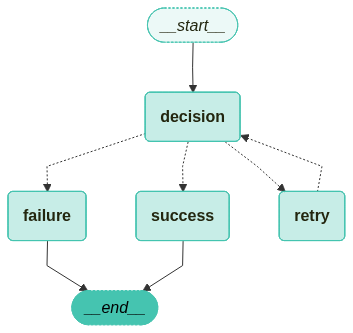

In [1]:
from feature.EdgeConditionalUseCommand import EdgeConditionalUseCommand

workflow = EdgeConditionalUseCommand()
workflow.show_graph()

In [2]:
# 그래프 실행
test_values = [30, 75, 150]
for val in test_values:
    result = workflow.invoke({"value": val, "message": "", "path": []})
    print(f"초기값 {val}:")
    print(f"  경로: {' → '.join(result['path'])}")
    print(f"  메시지: {result['message']}")
    print(f"  최종값: {result['value']}\n")


🔄 Node: decision 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
message:
재시도 필요
value:
60
decision

🔄 Node: retry 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
message:
재시도 중...
decision
retry

🔄 Node: decision 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
message:
처리 성공
value:
120
decision
retry
decision

🔄 Node: success 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
message:
[성공] 처리 성공
decision
retry
decision
success
초기값 30:
  경로: decision → retry → decision → success
  메시지: [성공] 처리 성공
  최종값: 120


🔄 Node: decision 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
message:
처리 성공
value:
150
decision

🔄 Node: success 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
message:
[성공] 처리 성공
decision
success
초기값 75:
  경로: decision → success
  메시지: [성공] 처리 성공
  최종값: 150


🔄 Node: decision 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
message:
값이 너무 큽니다
decision

🔄 Node: failure 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
message:
[실패] 값이 너무 큽니다